## 4. Key Insights from EDA

- **Headline Characteristics**: Typical headlines are 80–100 characters (~12–15 words), providing concise market information.
- **Coverage Imbalance**: Some stocks dominate analyst attention, which may introduce bias in sentiment-return correlations.
- **Temporal Trends**: Publication volume peaks align with major market events or earnings seasons; sparse periods may limit correlation analysis.
- **Data Quality**: Mixed-timezone dates required normalization; all data successfully standardized to UTC.

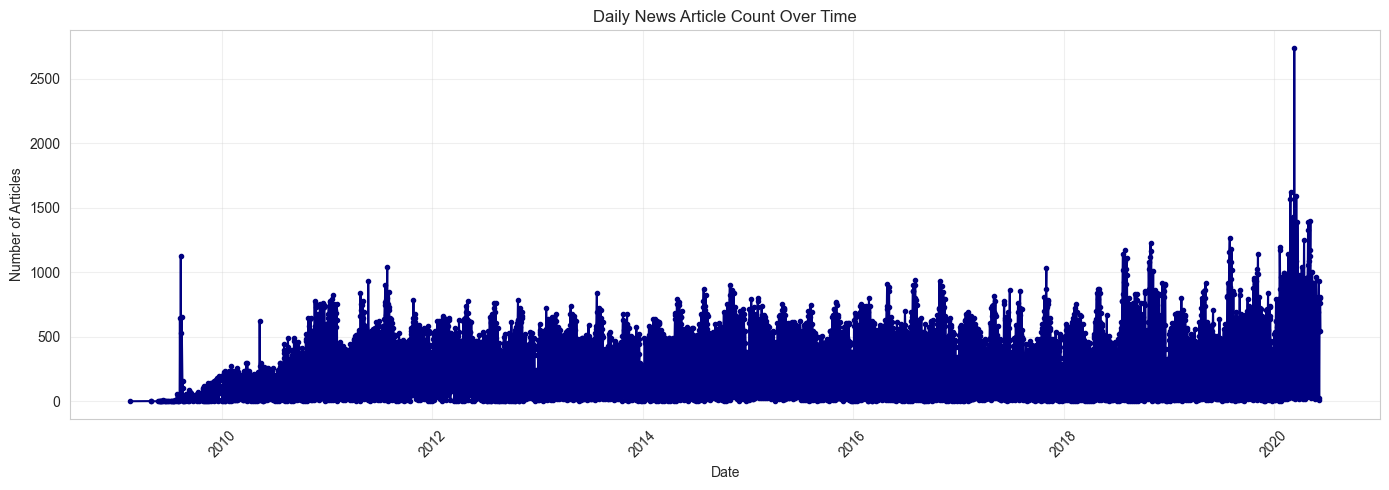

Publication Timeline:
  Date Range: 2009-02-14 to 2020-06-11
  Average Articles/Day: 355.8
  Peak Day: 2020-03-12 (2739 articles)


In [7]:
# Convert date column and create timeline
news['date'] = pd.to_datetime(news['date'], utc=True, format='mixed', errors='coerce')
daily_count = news.groupby(news['date'].dt.date).size()

fig, ax = plt.subplots(figsize=(14, 5))
daily_count.plot(ax=ax, color='navy', linewidth=1.5, marker='o', markersize=3)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Articles')
ax.set_title('Daily News Article Count Over Time')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Publication Timeline:")
print(f"  Date Range: {daily_count.index.min()} to {daily_count.index.max()}")
print(f"  Average Articles/Day: {daily_count.mean():.1f}")
print(f"  Peak Day: {daily_count.idxmax()} ({daily_count.max()} articles)")

## 3. Publication Timeline

How are articles distributed over time?

In [ ]:
# Stock coverage
stock_coverage = news['stock'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
stock_coverage.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('Stock Ticker')
ax.set_ylabel('Number of Articles')
ax.set_title('News Article Coverage by Stock')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Coverage by Stock:")
print(stock_coverage)
print(f"\nTotal Articles: {len(news)}")

## 2. Stock Coverage Distribution

Which stocks receive the most analyst attention?

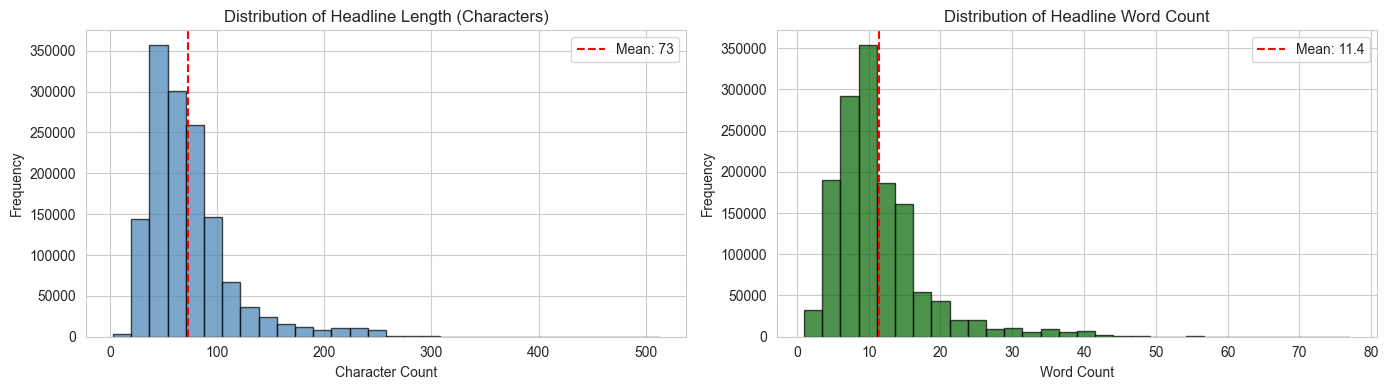

Headline Length Statistics:
  Mean: 73.1 characters
  Median: 64.0 characters
  Min: 3 | Max: 512

Word Count Statistics:
  Mean: 11.4 words
  Median: 10.0 words


In [ ]:
# Compute headline lengths
news['headline_length'] = news['headline'].str.len()
news['word_count'] = news['headline'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of headline lengths
axes[0].hist(news['headline_length'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Headline Length (Characters)')
axes[0].axvline(news['headline_length'].mean(), color='red', linestyle='--', label=f"Mean: {news['headline_length'].mean():.0f}")
axes[0].legend()

# Histogram of word counts
axes[1].hist(news['word_count'], bins=30, color='darkgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Headline Word Count')
axes[1].axvline(news['word_count'].mean(), color='red', linestyle='--', label=f"Mean: {news['word_count'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Headline Length Statistics:")
print(f"  Mean: {news['headline_length'].mean():.1f} characters")
print(f"  Median: {news['headline_length'].median():.1f} characters")
print(f"  Min: {news['headline_length'].min()} | Max: {news['headline_length'].max()}")
print(f"\nWord Count Statistics:")
print(f"  Mean: {news['word_count'].mean():.1f} words")
print(f"  Median: {news['word_count'].median():.1f} words")

## 1. Headline Length Distribution

Understanding headline length helps identify typical article styles and potential bias in coverage.

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
from src.data_loader import load_news
news = load_news()
print(f"Loaded {len(news)} news headlines")
print(f"\nColumns: {news.columns.tolist()}")
print(f"\nFirst few rows:")
news.head()

Loaded 1407328 news headlines

Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First few rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


# Exploratory Data Analysis: Financial News Headlines

This notebook analyzes the structure and content of financial news headlines to understand publication patterns, sentiment distribution, and key topics driving market discussion.